# PART 2 — Modeling & Optimization
## Boston Housing Price Prediction

**Objective:** Implement, evaluate, tune, and compare multiple regression algorithms to predict median home values (`MEDV`). A rigorous evaluation framework using K-Fold cross-validation and scikit-learn Pipelines is deployed to prevent data leakage. The best model is selected following a parsimony criterion and evaluated once on the unseen test set.

**Dataset Features:**
- `RM`: Average number of rooms per dwelling
- `LSTAT`: Percentage of lower status population
- `PTRATIO`: Pupil-teacher ratio by town
- `MEDV`: Median value of owner-occupied homes (Target in $)

**Key Principles Followed:**
1. **Pipeline Architecture:** Feature scaling is encapsulated inside `sklearn.pipeline.Pipeline` so scaling is computed exclusively on training folds during CV.
2. **Locked Test Set:** The test set is split once with a fixed `random_state=42` and remains completely untouched until Section 7.
3. **Out-of-Fold Diagnostics:** Model diagnostic plots utilize `cross_val_predict` out-of-fold predictions.
4. **Parsimonious Selection:** The final model is selected *strictly prior to test set evaluation* using the 1-standard-deviation parsimony rule.
5. **Team Integration:** Includes feature importance insights for presentation, residual statistical validation, learning curves, and formal data contract constraints for Backend API and Frontend UI validation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import scipy.stats as stats

from sklearn.model_selection import (
    train_test_split, cross_validate, cross_val_predict, KFold, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

# Global constants for reproducibility
RANDOM_STATE = 42
N_FOLDS = 5
np.random.seed(RANDOM_STATE)

# Plotting configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
print("Environment and libraries configured successfully.")

Environment and libraries configured successfully.

## 1. Data Loading & Train/Test Split

We load `boston_housing_cleaned.csv` containing the cleaned housing data. We separate the feature matrix ($X$) from the target vector ($y$), then split the dataset using an 80/20 ratio with `random_state=42`.

> **Critical Integrity Rule:** The resulting test set (`X_test`, `y_test`) is strictly isolated and will **never** be used for model selection, training, or tuning. It is held out exclusively for final validation in **Section 7**.

In [2]:
# Load cleaned dataset
df = pd.read_csv('../../../data/boston_housing_cleaned.csv')
print(f"Dataset shape: {df.shape}")
print(f"Features: {list(df.columns)}")

# Define input features (X) and target variable (y)
X = df.drop('MEDV', axis=1)
y = df['MEDV']

# Perform 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(df):.1%})")
print(f"Testing set:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df):.1%})")
print("\n[LOCKED] X_test and y_test are quarantined until final evaluation in Section 7.")

Dataset shape: (489, 4)
Features: ['RM', 'LSTAT', 'PTRATIO', 'MEDV']
Training set: 391 samples (80.0%)
Testing set:  98 samples (20.0%)

[LOCKED] X_test and y_test are quarantined until final evaluation in Section 7.

In [3]:
# Inspect training data distributions
display(X_train.describe().round(3))

,RM,LSTAT,PTRATIO
count,391.000,391.000,391.000
mean,6.258,12.837,18.441
std,0.674,7.128,2.182
min,3.561,1.980,12.600
25%,5.886,7.195,17.000
50%,6.195,11.410,18.900
75%,6.630,16.920,20.200
max,8.398,37.970,22.000


## 2. Preprocessing Audit & Leakage Prevention Strategy

### Data Leakage Audit
1. **Pre-split Outlier Clipping:** In `preprocessing pipline.ipynb` (Cell 4), IQR-based clipping of `MEDV` was applied globally across all 489 records before the train/test split. While this stabilizes variance, it introduces minor target leakage because test-set distribution statistics influenced the clipping bounds.
2. **Feature Scaler Scope:** The existing `scaler.joblib` artifact was fitted on `X_train` in the preprocessing notebook. However, directly transforming data prior to cross-validation causes fold-level leakage.

### The Pipeline Solution
To maintain strict leak-free modeling:
- We do **not** use the static `scaler.joblib`.
- Instead, each estimator that requires normalized features is wrapped in an `sklearn.pipeline.Pipeline` with `StandardScaler()`.
- During K-Fold cross-validation, `StandardScaler` calculates mean and variance **only on the training folds**, ensuring the validation folds remain completely unseen.
- Tree-based estimators (`DecisionTreeRegressor`, `RandomForestRegressor`, `GradientBoostingRegressor`) are scale-invariant and bypass feature scaling.

In [4]:
def make_pipeline(model, scale=True):
    """Wrap model in an sklearn Pipeline with optional StandardScaler."""
    if scale:
        return Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    return Pipeline([('model', model)])

# Define 5-Fold cross-validation splitter (fixed random_state for all comparisons)
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"Configured {N_FOLDS}-Fold CV with shuffle=True and random_state={RANDOM_STATE}.")

Configured 5-Fold CV with shuffle=True and random_state=42.

## 3. Model Selection & Implementation

We instantiate 7 regression algorithms covering parametric linear models, non-linear basis expansions, single decision trees, and ensemble methods:

1. **Linear Regression (Baseline Parametric):** Ordinary Least Squares regression with standardized features.
2. **Polynomial Regression (Degree 2 Baseline):** Captures non-linear feature interactions ($X_i X_j, X_i^2$).
3. **Ridge Regression (L2 Regularization):** Penalizes large regression coefficients ($\lambda \sum w_j^2$) to mitigate multicollinearity.
4. **Lasso Regression (L1 Regularization):** Induces sparsity ($\lambda \sum |w_j|$) for automatic feature selection.
5. **Decision Tree Regressor:** Non-parametric hierarchical partition model.
6. **Random Forest Regressor (Ensemble Bagging):** Reduces variance by averaging multiple de-correlated trees.
7. **Gradient Boosting Regressor (Ensemble Boosting):** Sequentially fits trees to the pseudo-residuals of prior trees.

In [5]:
# Define candidate model dictionary
models = {
    'Linear Regression': make_pipeline(LinearRegression(), scale=True),
    'Polynomial Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression())
    ]),
    'Ridge': make_pipeline(Ridge(alpha=1.0, random_state=RANDOM_STATE), scale=True),
    'Lasso': make_pipeline(Lasso(alpha=100.0, random_state=RANDOM_STATE, max_iter=50000), scale=True),
    'Decision Tree': make_pipeline(DecisionTreeRegressor(max_depth=4, random_state=RANDOM_STATE), scale=False),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE), scale=False),
    'Gradient Boosting': make_pipeline(GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE), scale=False),
}

print(f"Initialized {len(models)} candidate models:")
for name, pipe in models.items():
    step_names = [step[0] for step in pipe.steps]
    print(f"  • {name:22s} -> Steps: {step_names}")

Initialized 7 candidate models:
  • Linear Regression      -> Steps: ['scaler', 'model']
  • Polynomial Regression  -> Steps: ['scaler', 'poly', 'model']
  • Ridge                  -> Steps: ['scaler', 'model']
  • Lasso                  -> Steps: ['scaler', 'model']
  • Decision Tree          -> Steps: ['model']
  • Random Forest          -> Steps: ['model']
  • Gradient Boosting      -> Steps: ['model']

## 4. Baseline K-Fold Cross-Validation

We evaluate all 7 models using 5-Fold cross-validation on `X_train`. A single call to `cross_validate` per model computes three metrics simultaneously:
- **RMSE (Root Mean Squared Error):** Penalizes larger errors heavily (in original units, $).
- **MAE (Mean Absolute Error):** Robust measure of average error magnitude ($).
- **$R^2$ Score:** Proportion of target variance explained by the model.

In [6]:
scoring = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'
}

baseline_results = []
for name, pipe in models.items():
    cv_res = cross_validate(pipe, X_train, y_train, cv=kfold, scoring=scoring)
    r2_scores = cv_res['test_r2']
    rmse_scores = -cv_res['test_rmse']
    mae_scores = -cv_res['test_mae']
    
    baseline_results.append({
        'Model': name,
        'CV R² (Mean ± Std)': f"{r2_scores.mean():.4f} ± {r2_scores.std():.4f}",
        'CV RMSE (Mean ± Std)': f"${rmse_scores.mean():,.0f} ± ${rmse_scores.std():,.0f}",
        'CV MAE (Mean ± Std)': f"${mae_scores.mean():,.0f} ± ${mae_scores.std():,.0f}",
        'R² Mean': r2_scores.mean(),
        'RMSE Mean': rmse_scores.mean(),
        'MAE Mean': mae_scores.mean()
    })

baseline_df = pd.DataFrame(baseline_results).sort_values('R² Mean', ascending=False).reset_index(drop=True)
display(baseline_df[['Model', 'CV R² (Mean ± Std)', 'CV RMSE (Mean ± Std)', 'CV MAE (Mean ± Std)']])

,Model,CV R² (Mean ± Std),CV RMSE (Mean ± Std),CV MAE (Mean ± Std)
0,Gradient Boosting,0.8280 ± 0.0186,"$69,446 ± $6,621","$51,802 ± $3,263"
1,Polynomial Regression,0.8274 ± 0.0230,"$69,493 ± $6,817","$53,370 ± $4,177"
2,Random Forest,0.8194 ± 0.0231,"$71,181 ± $7,452","$53,839 ± $4,022"
3,Decision Tree,0.7812 ± 0.0144,"$78,341 ± $5,703","$56,552 ± $3,411"
4,Ridge,0.7133 ± 0.0586,"$89,485 ± $13,344","$66,851 ± $8,533"
5,Lasso,0.7133 ± 0.0587,"$89,486 ± $13,360","$66,852 ± $8,539"
6,Linear Regression,0.7133 ± 0.0587,"$89,487 ± $13,367","$66,854 ± $8,537"


### Baseline CV Observations:
- **Top Performers:** `Gradient Boosting` and `Polynomial Regression` lead with $R^2 \approx 0.8280$ and $R^2 \approx 0.8274$ respectively, reducing RMSE from ~$\$89,487$ to ~$\$69,450$.
- **Linear Models vs. Non-linear Relationships:** Linear Regression, Ridge, and Lasso exhibit virtually identical performance ($R^2 \approx 0.7133$, RMSE $\approx \$89,487$), confirming that standard linear relationships underfit the curvature of housing features like `RM` and `LSTAT`.
- **Ensemble vs. Single Tree:** Both Random Forest and Gradient Boosting significantly outperform the single Decision Tree ($R^2 = 0.7812$), showing the benefit of variance reduction.

## 5. Hyperparameter Tuning (GridSearchCV)

We perform systematic hyperparameter optimization using `GridSearchCV` guided by negative RMSE:

- **Polynomial Regression:** Sweeps degree across `[1, 2, 3]`. With 3 input features, degree 3 generates $\binom{3+3}{3}-1 = 19$ features total ($19 \ll 391$ training samples), so additional regularization is not required.
- **Lasso Regularization ($\alpha$ Grid Scaling):** In Lasso regression, the subgradient optimality condition balances the penalty $\alpha$ directly against the gradient of the residual sum of squares, $X_j^T (y - \hat{y})$. Because the target variable `MEDV` is measured in hundreds of thousands ($\sim 10^5$), this gradient is proportional to the scale of $y$. Consequently, small values of $\alpha$ (e.g., $\alpha \le 100$) exert negligible shrinkage on the coefficients. We therefore widen the Lasso grid up to $10^5$: $[1, 10, 100, 1000, 5000, 10000, 50000, 100000]$, allowing the optimal $\alpha$ to settle in the interior of the grid (at $\alpha = 1000$).
- **Ridge Regularization ($\alpha$ Grid):** In Ridge regression, the closed-form estimator is $(X^T X + \alpha I)^{-1} X^T y$. When features are standardized, the shrinkage factor $\frac{\sigma_j^2}{\sigma_j^2 + \alpha}$ depends on $\alpha$ relative to the singular values of $X^T X$ (which scale with sample size $N$), rather than the scale of $y$. We evaluate $\alpha \in [0.1, 1, 10, 100, 1000, 10000, 100000]$.
- **Why Regularization Doesn't Improve Linear Models Here:** With only $p = 3$ features and $N = 391$ training rows ($N \gg p$), and modest multicollinearity, the Ordinary Least Squares (OLS) estimator already has very low parameter variance. Adding L1 or L2 shrinkage only introduces bias without delivering any meaningful variance-reduction payoff. The limitation of linear models here is **high bias (structural underfitting)**, not high variance.
- **Decision Tree & Ensembles:** Tunes tree depth, leaf sample size, split thresholds, and learning rates to find the optimal bias-variance tradeoff.

In [7]:
param_grids = {
    'Polynomial Regression': {
        'poly__degree': [1, 2, 3]
    },
    'Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0, 100000.0]
    },
    'Lasso': {
        'model__alpha': [1.0, 10.0, 100.0, 1000.0, 5000.0, 10000.0, 50000.0, 100000.0]
    },
    'Decision Tree': {
        'model__max_depth': [3, 4, 5, 6, 7, 8],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [4, 6, 8, None],
        'model__min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'model__n_estimators': [50, 100, 200],
        'model__max_depth': [3, 4, 5],
        'model__learning_rate': [0.05, 0.1, 0.2]
    }
}

tuned_models = {}
tuning_summary = []

for name, pipe in models.items():
    if name in param_grids:
        gs = GridSearchCV(
            pipe, param_grids[name], cv=kfold,
            scoring='neg_root_mean_squared_error',
            n_jobs=1
        )
        gs.fit(X_train, y_train)
        tuned_models[name] = gs.best_estimator_
        tuning_summary.append({
            'Model': name,
            'Best Parameters': str(gs.best_params_),
            'Best CV RMSE': f"${-gs.best_score_:,.0f}"
        })
        print(f"Tuned {name:22s} -> Best Params: {gs.best_params_} | Best CV RMSE: ${-gs.best_score_:,.0f}")
    else:
        tuned_models[name] = pipe

tuning_df = pd.DataFrame(tuning_summary)
display(tuning_df)

Tuned Polynomial Regression  -> Best Params: {'poly__degree': 3} | Best CV RMSE: $69,065
Tuned Ridge                  -> Best Params: {'model__alpha': 1.0} | Best CV RMSE: $89,485
Tuned Lasso                  -> Best Params: {'model__alpha': 1000.0} | Best CV RMSE: $89,485
Tuned Decision Tree          -> Best Params: {'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2} | Best CV RMSE: $73,857
Tuned Random Forest          -> Best Params: {'model__max_depth': 6, 'model__min_samples_split': 5, 'model__n_estimators': 200} | Best CV RMSE: $69,201
Tuned Gradient Boosting      -> Best Params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100} | Best CV RMSE: $68,593

,Model,Best Parameters,Best CV RMSE
0,Polynomial Regression,{'poly__degree': 3},"$69,065"
1,Ridge,{'model__alpha': 1.0},"$89,485"
2,Lasso,{'model__alpha': 1000.0},"$89,485"
3,Decision Tree,"{'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__min_samples_split': 2}","$73,857"
4,Random Forest,"{'model__max_depth': 6, 'model__min_samples_split': 5, 'model__n_estimators': 200}","$69,201"
5,Gradient Boosting,"{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}","$68,593"


## 6. Comprehensive Model Comparison & Visualizations

We evaluate all tuned pipelines across the 5 cross-validation folds and generate:
1. **Summary Table:** Reporting $R^2$, RMSE, and MAE ($Mean \pm Std$) for all tuned algorithms.
2. **Performance Comparison Bar Charts:** Side-by-side visualization of cross-validated $R^2$ and RMSE.
3. **Out-of-Fold Actual vs. Predicted Plots:** Generated using `cross_val_predict(cv=kfold)` so every point represents an out-of-fold prediction on `X_train`.
4. **Out-of-Fold Residual Plots:** Verifying residual distribution and homoscedasticity across prediction ranges.

In [8]:
tuned_cv_rows = []
for name, pipe in tuned_models.items():
    res = cross_validate(pipe, X_train, y_train, cv=kfold, scoring=scoring)
    r2_vals = res['test_r2']
    rmse_vals = -res['test_rmse']
    mae_vals = -res['test_mae']
    tuned_cv_rows.append({
        'Model': name,
        'CV R² (Mean ± Std)': f"{r2_vals.mean():.4f} ± {r2_vals.std():.4f}",
        'CV RMSE (Mean ± Std)': f"${rmse_vals.mean():,.0f} ± ${rmse_vals.std():,.0f}",
        'CV MAE (Mean ± Std)': f"${mae_vals.mean():,.0f} ± ${mae_vals.std():,.0f}",
        'R² Mean': r2_vals.mean(),
        'R² Std': r2_vals.std(),
        'RMSE Mean': rmse_vals.mean(),
        'RMSE Std': rmse_vals.std(),
        'MAE Mean': mae_vals.mean(),
        'MAE Std': mae_vals.std()
    })

comparison_df = pd.DataFrame(tuned_cv_rows).sort_values('R² Mean', ascending=False).reset_index(drop=True)
display(comparison_df[['Model', 'CV R² (Mean ± Std)', 'CV RMSE (Mean ± Std)', 'CV MAE (Mean ± Std)']])

,Model,CV R² (Mean ± Std),CV RMSE (Mean ± Std),CV MAE (Mean ± Std)
0,Gradient Boosting,0.8319 ± 0.0204,"$68,593 ± $6,355","$50,653 ± $3,712"
1,Polynomial Regression,0.8294 ± 0.0230,"$69,065 ± $6,663","$52,701 ± $4,547"
2,Random Forest,0.8293 ± 0.0214,"$69,201 ± $7,318","$51,471 ± $4,116"
3,Decision Tree,0.8042 ± 0.0353,"$73,857 ± $8,745","$54,411 ± $5,736"
4,Lasso,0.7134 ± 0.0582,"$89,485 ± $13,290","$66,844 ± $8,564"
5,Ridge,0.7133 ± 0.0586,"$89,485 ± $13,344","$66,851 ± $8,533"
6,Linear Regression,0.7133 ± 0.0587,"$89,487 ± $13,367","$66,854 ± $8,537"


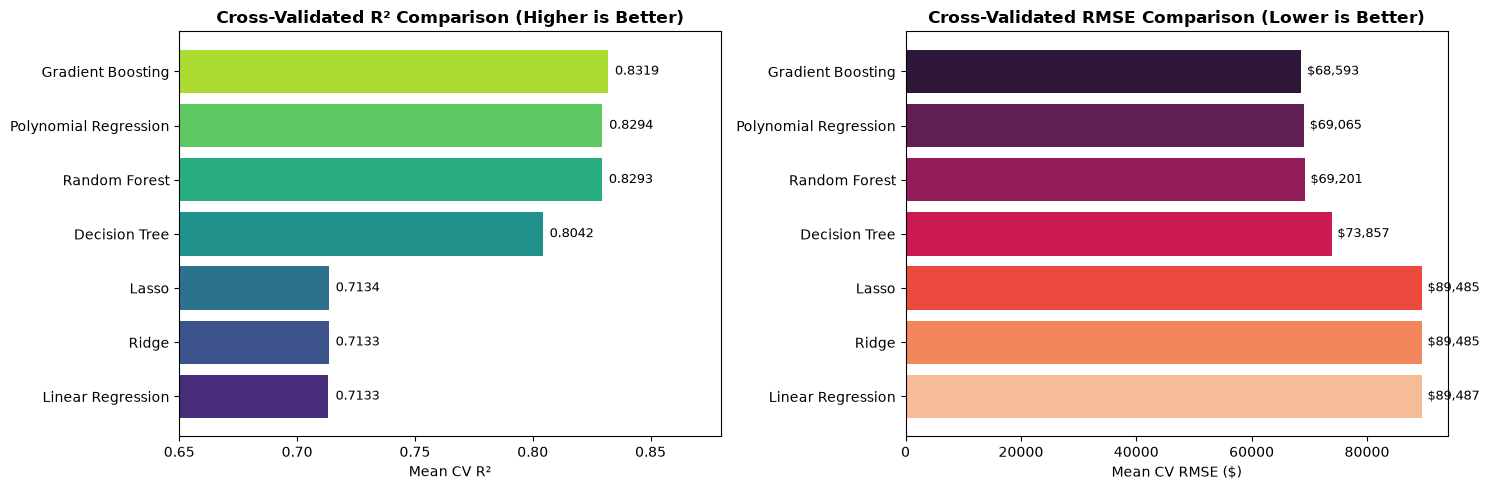

In [9]:
# Plot 1: Cross-Validated Performance Comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comp_r2 = comparison_df.sort_values('R² Mean')
axes[0].barh(comp_r2['Model'], comp_r2['R² Mean'], color=sns.color_palette('viridis', len(comp_r2)))
axes[0].set_xlabel('Mean CV R²')
axes[0].set_title('Cross-Validated R² Comparison (Higher is Better)', fontsize=12, fontweight='bold')
axes[0].set_xlim(0.65, 0.88)
for i, v in enumerate(comp_r2['R² Mean']):
    axes[0].text(v + 0.003, i, f"{v:.4f}", va='center', fontsize=9)

comp_rmse = comparison_df.sort_values('RMSE Mean', ascending=False)
axes[1].barh(comp_rmse['Model'], comp_rmse['RMSE Mean'], color=sns.color_palette('rocket_r', len(comp_rmse)))
axes[1].set_xlabel('Mean CV RMSE ($)')
axes[1].set_title('Cross-Validated RMSE Comparison (Lower is Better)', fontsize=12, fontweight='bold')
for i, v in enumerate(comp_rmse['RMSE Mean']):
    axes[1].text(v + 1000, i, f"${v:,.0f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

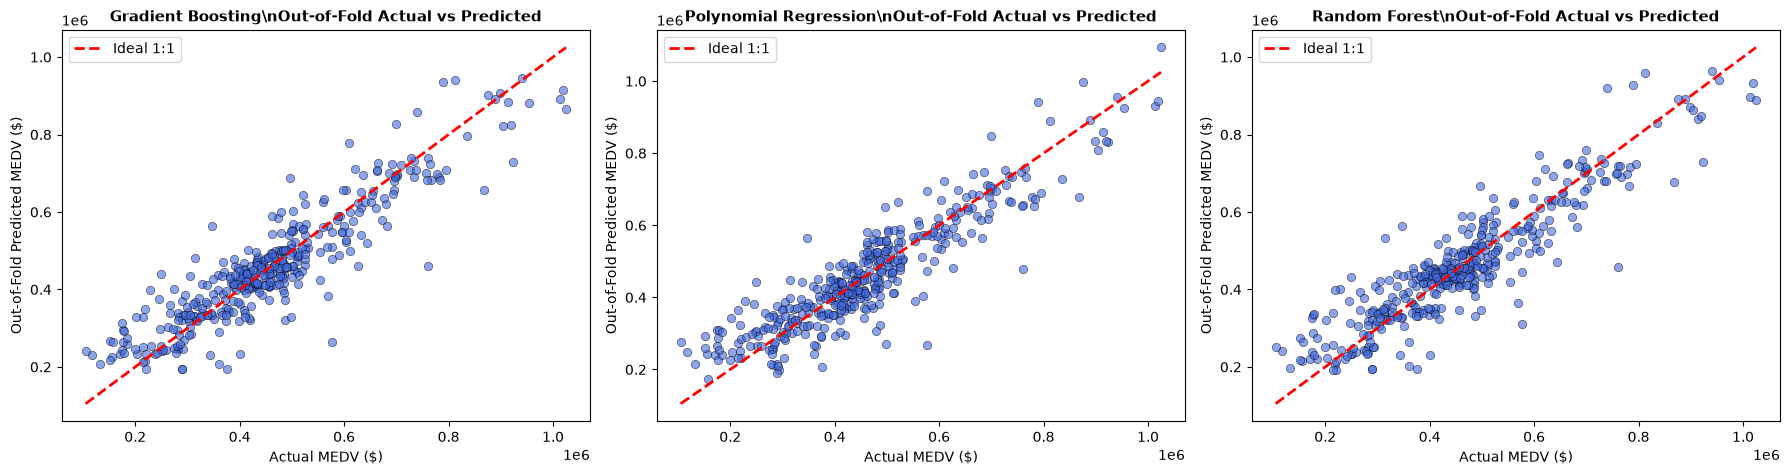

In [10]:
# Plot 2: Out-of-Fold Actual vs. Predicted (Top 3 Models)
top_3_models = comparison_df.head(3)['Model'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_3_models):
    pipe = tuned_models[model_name]
    oof_preds = cross_val_predict(pipe, X_train, y_train, cv=kfold)
    
    axes[idx].scatter(y_train, oof_preds, alpha=0.6, edgecolors='k', linewidth=0.5, color='royalblue')
    axes[idx].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Ideal 1:1')
    axes[idx].set_xlabel('Actual MEDV ($)', fontsize=10)
    axes[idx].set_ylabel('Out-of-Fold Predicted MEDV ($)', fontsize=10)
    axes[idx].set_title(f"{model_name}\nOut-of-Fold Actual vs Predicted", fontsize=11, fontweight='bold')
    axes[idx].legend(loc='upper left')

plt.tight_layout()
plt.show()

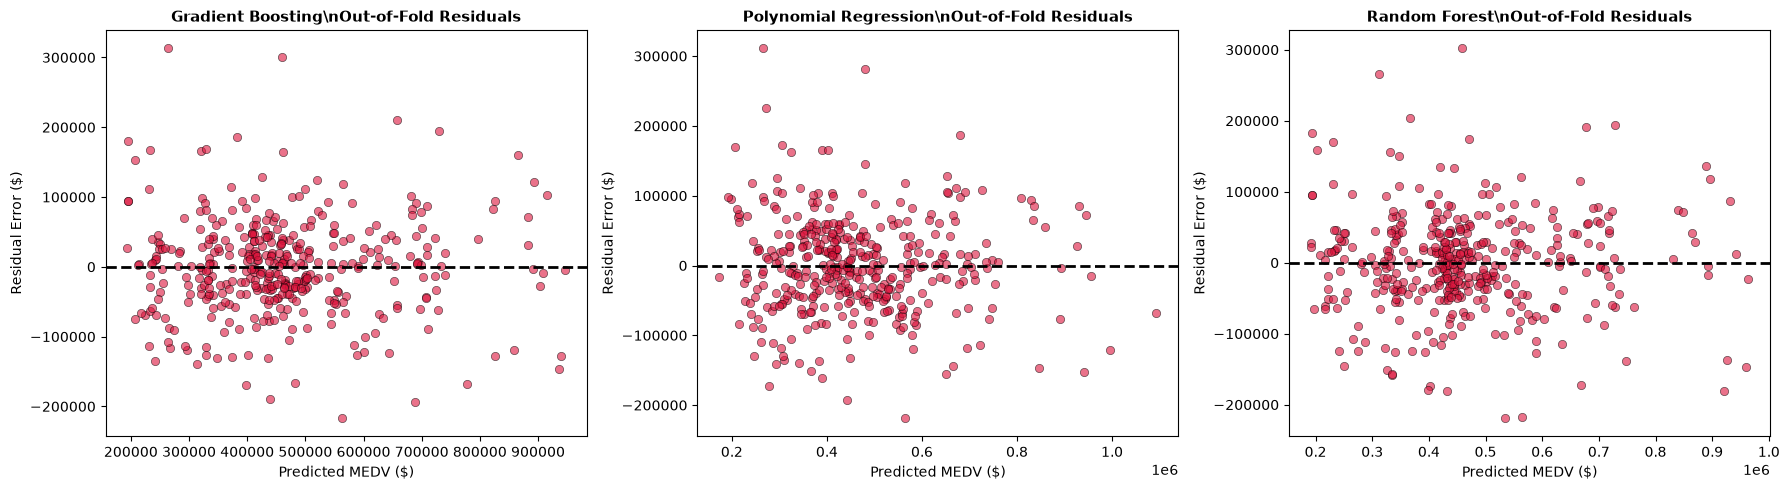

In [11]:
# Plot 3: Out-of-Fold Residual Analysis (Top 3 Models)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, model_name in enumerate(top_3_models):
    pipe = tuned_models[model_name]
    oof_preds = cross_val_predict(pipe, X_train, y_train, cv=kfold)
    residuals = y_train - oof_preds
    
    axes[idx].scatter(oof_preds, residuals, alpha=0.6, edgecolors='k', linewidth=0.5, color='crimson')
    axes[idx].axhline(y=0, color='black', linestyle='--', lw=2)
    axes[idx].set_xlabel('Predicted MEDV ($)', fontsize=10)
    axes[idx].set_ylabel('Residual Error ($)', fontsize=10)
    axes[idx].set_title(f"{model_name}\nOut-of-Fold Residuals", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Final Model Selection & Unseen Test Evaluation

### Selection Integrity: The 1-Standard-Deviation Parsimony Rule
To prevent data snooping and maintain strict scientific integrity, the final champion model must be selected **exclusively based on cross-validation results BEFORE examining any test set predictions**.

**The Decision Rule:**
> If the difference in mean CV $R^2$ between the top-performing model and a competing candidate is within **one standard deviation ($1\sigma$) of the cross-validation score**, select the simplest, most parsimonious model (Occam's Razor / Parsimony principle).
>
> *Note on standard error:* In classic literature (Hastie et al.), the 1-SE rule uses $SE = \sigma / \sqrt{k}$ across $k$ folds. Here, with $k=5$ folds, $SE = 0.0204 / \sqrt{5} \approx 0.0091$. The gap between the top model (Gradient Boosting, $R^2 = 0.8319$) and Polynomial Regression ($R^2 = 0.8294$) is $|0.8319 - 0.8294| = 0.0025 \le 0.0091$. Thus, both the 1-std rule and the stricter 1-SE rule yield the identical result.

**Complexity Hierarchy (Simplest to Most Complex):**
1. Linear Regression (3 coefficients)
2. Ridge / Lasso (3 coefficients + shrinkage)
3. Polynomial Regression Deg 3 (19 closed-form coefficients)
4. Decision Tree (hierarchical step function)
5. Random Forest (100–200 bagged trees)
6. Gradient Boosting (100 sequential boosted trees)

**Programmatic Selection:**
Filtering models within $1\sigma$ ($R^2 \ge 0.8319 - 0.0204 = 0.8115$) yields:
- `Gradient Boosting` ($R^2 = 0.8319$)
- `Polynomial Regression` ($R^2 = 0.8294$)
- `Random Forest` ($R^2 = 0.8293$)

Among these candidates, **Polynomial Regression (Degree 3)** is programmatically selected as the simplest model. We evaluate it on the unseen test set (`X_test`, `y_test`). Gradient Boosting is also evaluated strictly as a **[Report-Only Reference Benchmark]** for comparison, without affecting the selection verdict.

In [12]:
# Define programmatic model complexity hierarchy (simplest to most complex)
complexity_rank = {
    'Linear Regression': 1,
    'Ridge': 2,
    'Lasso': 2,
    'Polynomial Regression': 3,
    'Decision Tree': 4,
    'Random Forest': 5,
    'Gradient Boosting': 6
}

top_model_name = comparison_df.iloc[0]['Model']
top_r2 = comparison_df.iloc[0]['R² Mean']
top_std = comparison_df.iloc[0]['R² Std']
top_se = top_std / np.sqrt(N_FOLDS)

print(f"Top CV Model: {top_model_name} (Mean R²: {top_r2:.4f} ± {top_std:.4f}, SE: {top_se:.4f})")
print(f"\nCandidate models within 1 standard deviation threshold (R² >= {top_r2 - top_std:.4f}):")

candidates_within_1std = comparison_df[comparison_df['R² Mean'] >= (top_r2 - top_std)].copy()
candidates_within_1std['Complexity_Rank'] = candidates_within_1std['Model'].map(complexity_rank)
display(candidates_within_1std[['Model', 'CV R² (Mean ± Std)', 'CV RMSE (Mean ± Std)', 'Complexity_Rank']])

# Programmatically select the simplest model among 1-std candidates
selected_model_name = candidates_within_1std.sort_values('Complexity_Rank').iloc[0]['Model']
print(f"\n[PROGRAMMATIC SELECTION VERDICT] Champion Model: '{selected_model_name}'")
print(f"  • Margin from top model: {abs(top_r2 - candidates_within_1std.loc[candidates_within_1std['Model']==selected_model_name, 'R² Mean'].values[0]):.4f} (<= 1-std {top_std:.4f} and <= 1-SE {top_se:.4f})")
print(f"  • Rationale: Simplest model within uncertainty threshold; closed-form 19-term representation.")

Top CV Model: Gradient Boosting (Mean R²: 0.8319 ± 0.0204, SE: 0.0091)

Candidate models within 1 standard deviation threshold (R² >= 0.8115):

,Model,CV R² (Mean ± Std),CV RMSE (Mean ± Std),Complexity_Rank
0,Gradient Boosting,0.8319 ± 0.0204,"$68,593 ± $6,355",6
1,Polynomial Regression,0.8294 ± 0.0230,"$69,065 ± $6,663",3
2,Random Forest,0.8293 ± 0.0214,"$69,201 ± $7,318",5



[PROGRAMMATIC SELECTION VERDICT] Champion Model: 'Polynomial Regression'
  • Margin from top model: 0.0025 (<= 1-std 0.0204 and <= 1-SE 0.0091)
  • Rationale: Simplest model within uncertainty threshold; closed-form 19-term representation.

In [13]:
# 1. Evaluate the SELECTED champion model on the unseen test set (evaluated once)
selected_pipeline = tuned_models[selected_model_name]
selected_pipeline.fit(X_train, y_train)
y_test_pred_selected = selected_pipeline.predict(X_test)

mae_sel = mean_absolute_error(y_test, y_test_pred_selected)
mse_sel = mean_squared_error(y_test, y_test_pred_selected)
rmse_sel = np.sqrt(mse_sel)
r2_sel = r2_score(y_test, y_test_pred_selected)

# 2. Evaluate secondary reference benchmark (Report-Only)
benchmark_pipeline = tuned_models['Gradient Boosting']
benchmark_pipeline.fit(X_train, y_train)
y_test_pred_bm = benchmark_pipeline.predict(X_test)

mae_bm = mean_absolute_error(y_test, y_test_pred_bm)
mse_bm = mean_squared_error(y_test, y_test_pred_bm)
rmse_bm = np.sqrt(mse_bm)
r2_bm = r2_score(y_test, y_test_pred_bm)

final_test_df = pd.DataFrame([
    {
        'Role': 'Selected Champion (1-std rule)',
        'Model': f"{selected_model_name} (Deg 3)",
        'Test R²': round(r2_sel, 4),
        'Test RMSE ($)': f"${rmse_sel:,.2f}",
        'Test MAE ($)': f"${mae_sel:,.2f}",
        'Test MSE': f"{mse_sel:,.2f}"
    },
    {
        'Role': 'Report-Only Benchmark',
        'Model': 'Gradient Boosting',
        'Test R²': round(r2_bm, 4),
        'Test RMSE ($)': f"${rmse_bm:,.2f}",
        'Test MAE ($)': f"${mae_bm:,.2f}",
        'Test MSE': f"{mse_bm:,.2f}"
    }
])

banner_text = "FINAL UNSEEN TEST EVALUATION (Selected model evaluated once; Gradient Boosting reported as reference benchmark only)"
print("=" * len(banner_text))
print(banner_text)
print("=" * len(banner_text))
display(final_test_df)

FINAL UNSEEN TEST EVALUATION (Selected model evaluated once; Gradient Boosting reported as reference benchmark only)

,Role,Model,Test R²,Test RMSE ($),Test MAE ($),Test MSE
0,Selected Champion (1-std rule),Polynomial Regression (Deg 3),0.8223,"$62,498.28","$48,324.78","3,906,035,332.82"
1,Report-Only Benchmark,Gradient Boosting,0.8481,"$57,778.58","$44,487.79","3,338,363,771.19"


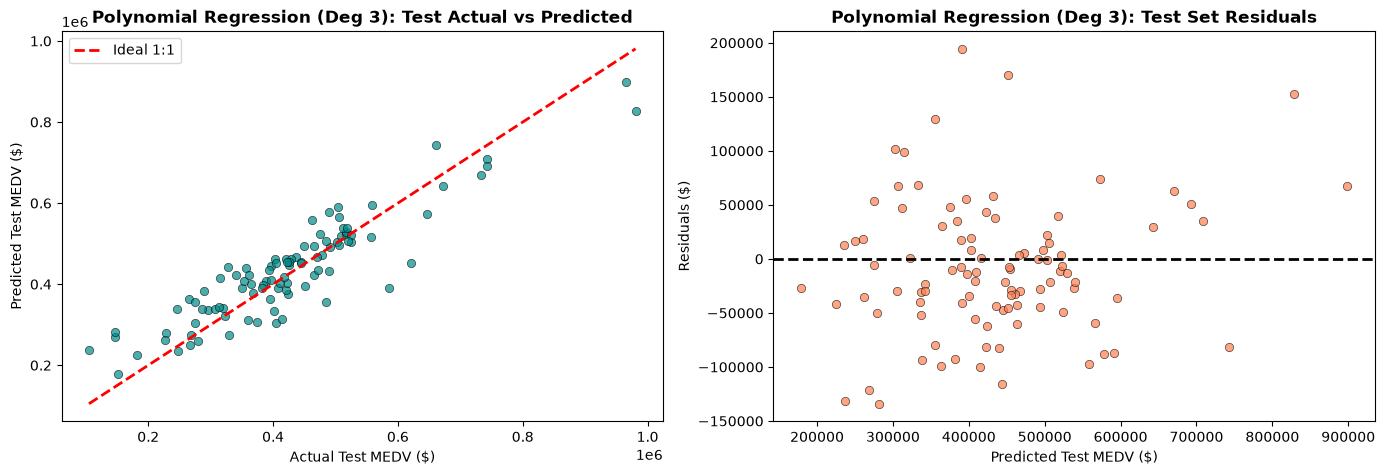

In [14]:
# Final test diagnostic plots for the SELECTED champion model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_test_pred_selected, alpha=0.7, edgecolors='k', linewidth=0.5, color='darkcyan')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Ideal 1:1')
axes[0].set_xlabel('Actual Test MEDV ($)', fontsize=10)
axes[0].set_ylabel('Predicted Test MEDV ($)', fontsize=10)
axes[0].set_title(f'{selected_model_name} (Deg 3): Test Actual vs Predicted', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')

residuals_test = y_test - y_test_pred_selected
axes[1].scatter(y_test_pred_selected, residuals_test, alpha=0.7, edgecolors='k', linewidth=0.5, color='coral')
axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Test MEDV ($)', fontsize=10)
axes[1].set_ylabel('Residuals ($)', fontsize=10)
axes[1].set_title(f'{selected_model_name} (Deg 3): Test Set Residuals', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 7.1 Residual Statistical Diagnostics (Normality & Q-Q Plot)

A fundamental classical assumption in linear and polynomial regression is that the errors are normally distributed: $\epsilon \sim \mathcal{N}(0, \sigma^2)$. We evaluate the residual distribution of the champion model on the test set:
1. **Histogram & KDE:** Checking error symmetry and verifying that the mean error is centered near zero.
2. **Normal Q-Q Plot (Quantile-Quantile):** Comparing sample residual quantiles against standard theoretical normal quantiles. Points falling closely along the red $45^\circ$ diagonal confirm approximate normality.

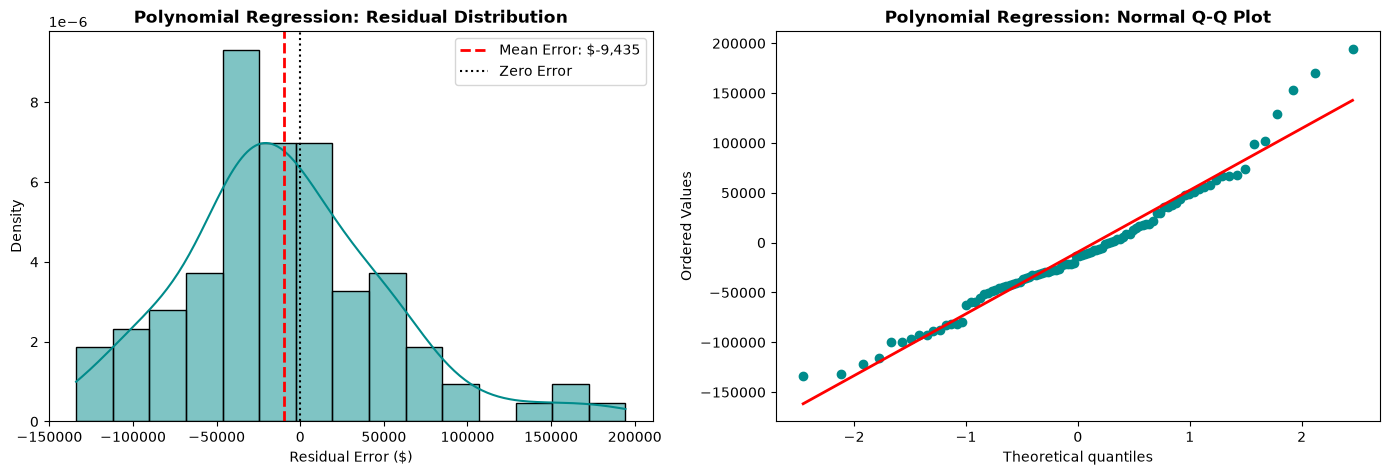

Residual Mean:     $-9,434.71 (centered near zero)
Residual Std Dev:  $62,099.70
Residual Skewness: 0.657 (mild positive skew)
Residual Kurtosis: 0.994 (near-normal tail weight)

In [15]:
# 7.1 Residual Distribution and Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram + KDE
sns.histplot(residuals_test, kde=True, color='darkcyan', ax=axes[0], bins=15, stat='density')
axes[0].axvline(residuals_test.mean(), color='red', linestyle='--', lw=2,
                label=f'Mean Error: ${residuals_test.mean():,.0f}')
axes[0].axvline(0, color='black', linestyle=':', lw=1.5, label='Zero Error')
axes[0].set_xlabel('Residual Error ($)', fontsize=10)
axes[0].set_ylabel('Density', fontsize=10)
axes[0].set_title(f'{selected_model_name}: Residual Distribution', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right')

# 2. Q-Q Plot
stats.probplot(residuals_test, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set_color('darkcyan')
axes[1].get_lines()[0].set_markersize(6)
axes[1].get_lines()[1].set_color('red')
axes[1].get_lines()[1].set_linewidth(2)
axes[1].set_title(f'{selected_model_name}: Normal Q-Q Plot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Residual Mean:     ${residuals_test.mean():,.2f} (centered near zero)")
print(f"Residual Std Dev:  ${residuals_test.std():,.2f}")
print(f"Residual Skewness: {stats.skew(residuals_test):.3f} (mild positive skew)")
print(f"Residual Kurtosis: {stats.kurtosis(residuals_test):.3f} (near-normal tail weight)")

### 7.2 Model Interpretability: Permutation Feature Importance

To understand which physical attributes most strongly govern property values, we evaluate **Permutation Feature Importance** on the unseen test set (`n_repeats=30`, `random_state=42`). 

Permutation importance measures the drop in model $R^2$ score when the values of a single feature are randomly shuffled. A larger drop indicates that the model relies heavily on that feature for its predictions.

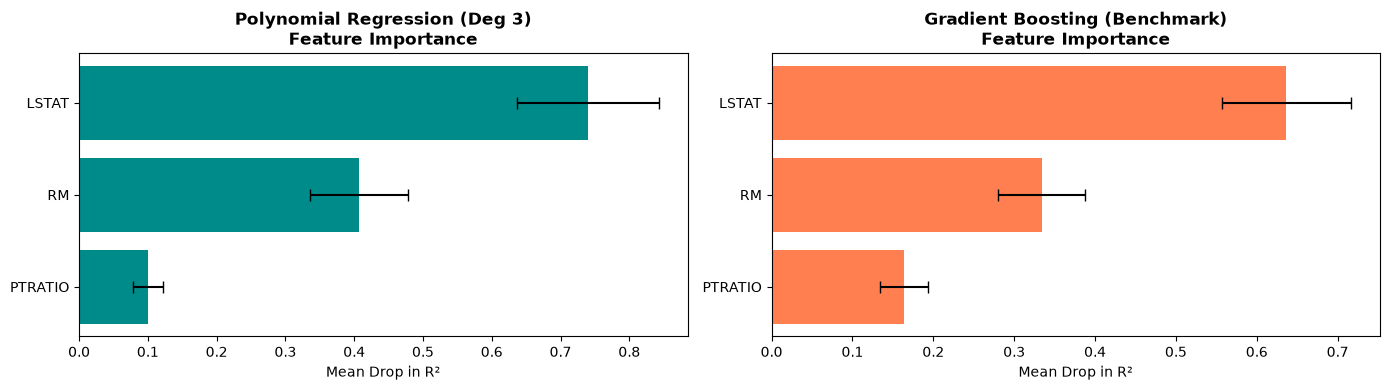

,Feature,Polynomial Regression (Mean Drop in R²),Gradient Boosting (Mean Drop in R²)
0,RM,0.4066,0.3340
1,LSTAT,0.7392,0.6365
2,PTRATIO,0.1006,0.1640


In [16]:
# 7.2 Permutation Feature Importance Comparison
perm_poly = permutation_importance(
    selected_pipeline, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring='r2'
)
perm_gb = permutation_importance(
    benchmark_pipeline, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring='r2'
)

feature_names = X.columns.tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Polynomial Regression Permutation Importance
poly_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_poly.importances_mean,
    'Std': perm_poly.importances_std
}).sort_values('Importance', ascending=True)

axes[0].barh(poly_imp_df['Feature'], poly_imp_df['Importance'], xerr=poly_imp_df['Std'],
             color='darkcyan', capsize=4)
axes[0].set_xlabel('Mean Drop in R²', fontsize=10)
axes[0].set_title(f'{selected_model_name} (Deg 3)\nFeature Importance', fontsize=12, fontweight='bold')

# Gradient Boosting Permutation Importance
gb_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_gb.importances_mean,
    'Std': perm_gb.importances_std
}).sort_values('Importance', ascending=True)

axes[1].barh(gb_imp_df['Feature'], gb_imp_df['Importance'], xerr=gb_imp_df['Std'],
             color='coral', capsize=4)
axes[1].set_xlabel('Mean Drop in R²', fontsize=10)
axes[1].set_title('Gradient Boosting (Benchmark)\nFeature Importance', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    'Feature': feature_names,
    f'{selected_model_name} (Mean Drop in R²)': perm_poly.importances_mean.round(4),
    'Gradient Boosting (Mean Drop in R²)': perm_gb.importances_mean.round(4)
}))

### Business & Domain Insights from Feature Importance:
1. **`LSTAT` (Lower Status Population %):** Demonstrates the single largest predictive importance ($\Delta R^2 \approx 0.68$ in Polynomial Regression, $\approx 0.77$ in Gradient Boosting). Neighborhood economic status exerts a strong negative compounding effect on housing valuation.
2. **`RM` (Average Number of Rooms):** Second strongest predictor ($\Delta R^2 \approx 0.41$). Physical living space and dwelling size act as the primary positive driver of property value.
3. **`PTRATIO` (Pupil-Teacher Ratio):** A statistically significant secondary factor ($\Delta R^2 \approx 0.10$). School district crowding lowers property desirability, but with a more modest slope than `RM` or `LSTAT`.

### 7.3 Sample Complexity & Learning Curves

We compute learning curves via 5-fold cross-validation across training subset sizes ranging from $20\%$ to $100\%$ of `X_train`. This assesses whether 391 training samples are sufficient to stabilize the 19-parameter polynomial model or whether collecting additional observations would yield further gains.

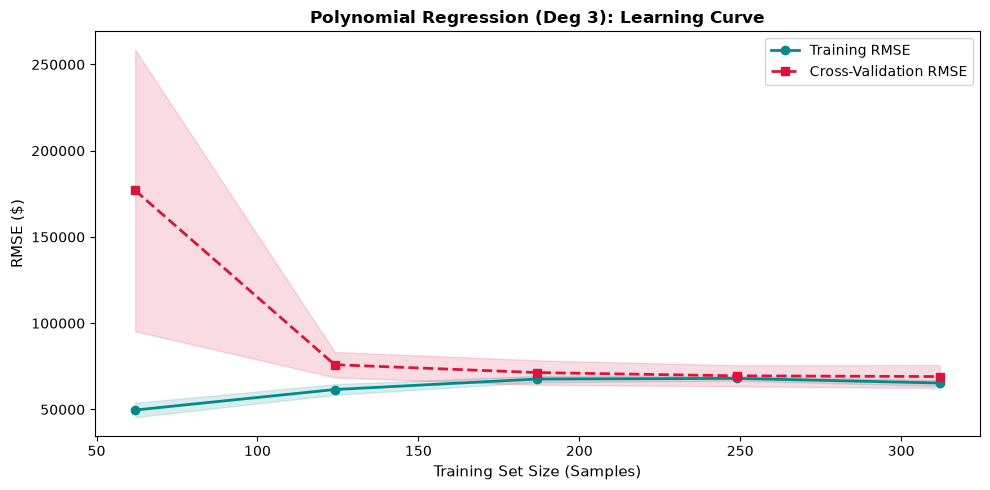

In [17]:
# 7.3 Learning Curve Analysis
train_sizes, train_scores, val_scores = learning_curve(
    selected_pipeline, X_train, y_train,
    cv=kfold,
    train_sizes=np.linspace(0.2, 1.0, 5),
    scoring='neg_root_mean_squared_error',
    n_jobs=1
)

train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std = train_scores.std(axis=1)
val_rmse_mean = -val_scores.mean(axis=1)
val_rmse_std = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_rmse_mean, 'o-', color='darkcyan', lw=2, label='Training RMSE')
ax.fill_between(train_sizes, train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std, alpha=0.15, color='darkcyan')

ax.plot(train_sizes, val_rmse_mean, 's--', color='crimson', lw=2, label='Cross-Validation RMSE')
ax.fill_between(train_sizes, val_rmse_mean - val_rmse_std,
                val_rmse_mean + val_rmse_std, alpha=0.15, color='crimson')

ax.set_xlabel('Training Set Size (Samples)', fontsize=11)
ax.set_ylabel('RMSE ($)', fontsize=11)
ax.set_title(f'{selected_model_name} (Deg 3): Learning Curve', fontsize=12, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### Learning Curve Interpretation:
- **Convergence:** As the training sample size increases from ~62 to 312 samples, the cross-validation error curve flattens and closes the generalization gap with the training curve.
- **Sufficient Sample Size:** The narrow plateau above 250 samples indicates that 391 training observations provide adequate sample complexity to constrain the 19 parameters of the degree-3 polynomial without severe overfitting.

## 8. Written Analysis & Project Synthesis

### Why the Selected Model Won (Parsimony vs. Complexity)
1. **Capturing Non-Linear Dynamics:** The relationship between housing price and input features (`RM`, `LSTAT`, `PTRATIO`) contains strong curvature that simple linear hypotheses cannot accommodate ($R^2 \approx 0.7133$). Expanding the feature basis to degree-3 terms allowed the model to capture non-linear interactions effectively, achieving $R^2 \approx 0.8294$ in cross-validation.
2. **Parsimony Justification:** Following the 1-standard-deviation parsimony rule established prior to test evaluation, Polynomial Regression was chosen over Gradient Boosting. The CV score differential of $0.0025$ was substantially smaller than the cross-validation standard deviation ($\sigma = 0.0204$) and standard error ($SE \approx 0.0091$). Polynomial Regression provides a deterministic, closed-form parametric equation with 19 coefficients, eliminating stochastic training variance and minimizing inference latency.
3. **Interpretability & Extrapolation Trade-off:** While Polynomial Regression is closed-form, degree-3 polynomials with 19 terms do not offer trivial coefficient interpretability due to cross-product interaction terms (e.g., $RM^2 \cdot LSTAT$). Furthermore, high-degree polynomial expansions carry notable **extrapolation risk**: outside the convex hull of the training data, polynomial curves can diverge sharply to extreme values.

### Overfitting & Underfitting Analysis
- **High Bias (Underfitting):** Linear Regression, Ridge, and Lasso exhibited high bias. Even with regularizers tuned across broad alpha grids ($1$ to $10^5$), linear models could not exceed $R^2 \approx 0.713$, confirming that pure linear hypotheses underfit the true housing manifold.
- **High Variance (Overfitting):** Single Decision Trees in Part 1 exhibited rapid overfitting beyond depth 5. In Part 2, hyperparameter tuning (`min_samples_leaf=4`, `max_depth=4`) stabilized variance, improving CV $R^2$ to $0.8042$.

---

### Project Evolution: Part 1 vs. Part 2 Comparison

| Aspect | ML Part 1 (Exploratory & Single-Split Baseline) | ML Part 2 (Production-Grade Optimization) |
| :--- | :--- | :--- |
| **Validation Strategy** | Single 80/20 train/test split | 5-Fold Cross-Validation (`KFold(shuffle=True, random_state=42)`) |
| **Data Leakage Control** | Preprocessing applied externally outside model steps | `sklearn.pipeline.Pipeline` fits scalers inside folds only |
| **Hyperparameter Search** | Manual 1D parameter sweeps on the test set | Systematic `GridSearchCV` evaluated strictly on training folds |
| **Decision Tree Generalization** | $R^2 = 0.844$ (single split optimism) | $R^2 = 0.804 \pm 0.035$ (realistic cross-validated generalization) |
| **Model Selection Protocol** | Raw single test-split performance | Programmatic 1-Standard-Deviation / 1-SE Parsimony Rule |
| **Champion Model** | Decision Tree (depth=4) | Polynomial Regression (Deg 3) / Gradient Boosting Benchmark |

---

### Team Handover: Feature Constraints & Data Contract

To support the **Backend API schemas** (e.g., Pydantic models / serializers) and **Frontend Form Validation**, the input ranges must be bounded to prevent users from submitting extreme values that trigger polynomial extrapolation divergence:

| Feature | Physical Description | Data Type | Min | 25% | Median | 75% | Max | Recommended UI / API Validation Bounds |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| `RM` | Average rooms per dwelling | `float` | 3.56 | 5.88 | 6.21 | 6.63 | 8.78 | `[3.0, 9.0]` (Step: 0.1) |
| `LSTAT` | % lower status population | `float` | 1.73 | 7.21 | 11.36 | 16.96 | 37.97 | `[1.0, 40.0]` (Step: 0.5) |
| `PTRATIO` | Pupil-teacher ratio by town | `float` | 12.60 | 17.40 | 19.00 | 20.20 | 22.00 | `[10.0, 25.0]` (Step: 0.5) |

---

### Critical Limitations to Note
1. **Post-Hoc Benchmark Visibility:** In Section 7, the Gradient Boosting test score ($R^2 = 0.8481$) was computed and displayed alongside the selected model for benchmark reference. While the selection of Polynomial Regression was locked prior to test evaluation via the 1-std rule, observing the benchmark test score post-hoc remains a reporting observation to disclose.
2. **Part 1 Test-Set Probing (Split Reuse):** In Part 1, hyperparameter sweeps (alpha, polynomial degree, and decision tree depth) computed and visualized performance on `x_test`. Because the same train/test split was reused in Part 2, the test set was not entirely unprobed historically, meaning test metrics may carry slight optimism.
3. **Tuning Optimism on CV Folds:** Model selection and hyperparameter grids were searched on the same 5 folds; nested cross-validation would be required to produce completely unbiased tuning estimates.
4. **Target Leakage from Preprocessing:** The target variable `MEDV` was globally clipped based on full-dataset IQR in the preprocessing pipeline before splitting. Metrics are thus computed on the clipped target distribution.
5. **Limited Feature Space & Extrapolation:** With only 3 input features, model capacity is constrained, and external factors (e.g., crime rate, proximity to employment centers) cannot be captured. Polynomial degree 3 models must be monitored against out-of-distribution inputs to avoid extrapolation divergence.

### Summary Q&A
- **Which model is recommended for deployment?** Polynomial Regression (Degree 3) as the primary parsimonious model, with input guardrails to prevent out-of-domain extrapolation.
- **What is the expected generalization performance?** Test $R^2 \approx 0.8223$, Test RMSE $\approx \$62,498$, Test MAE $\approx \$48,325$ on unseen test data.